# 🤖 AI Resume Screening System

### Resume–Job Matching using NLP, TF-IDF and BERT

**Project Objective:**  
To automatically analyze resumes and compare them with job descriptions using Natural Language Processing and Machine Learning techniques.

### Technologies Used
- Python
- Pandas
- Scikit-learn
- TF-IDF
- Cosine Similarity
- Sentence Transformers / BERT
- NLP
- Matplotlib

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

Matplotlib is building the font cache; this may take a moment.
C:\Users\kolam\Documents\CSE projects\AI-Resume-Screening-System\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
jobs_path = "../data/sample_jobs.csv"

jobs_df = pd.read_csv(jobs_path)

jobs_df.head()

,job_id,job_title,company,description,required_skills
0,1,Software Engineer,TCS,"Develop software applications, solve programmi...",Python;Java;SQL;Data Structures;Git;Object Ori...
1,2,Machine Learning Engineer,Tech Solutions,"Build machine learning models, preprocess data...",Python;Machine Learning;Scikit-learn;Pandas;Nu...
2,3,Data Analyst,Analytics Corp,"Analyze business data, create reports and iden...",Python;SQL;Pandas;NumPy;Matplotlib
3,4,AI Engineer,AI Labs,Develop artificial intelligence solutions usin...,Python;Machine Learning;Deep Learning;NLP;Tens...
4,5,Web Developer,Digital Systems,Develop responsive web applications and APIs u...,HTML;CSS;JavaScript;React;Node.js;Git


In [4]:
print("Number of job records:", len(jobs_df))
print("Number of columns:", len(jobs_df.columns))

jobs_df.info()

Number of job records: 5
Number of columns: 5
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   job_id           5 non-null      int64
 1   job_title        5 non-null      str  
 2   company          5 non-null      str  
 3   description      5 non-null      str  
 4   required_skills  5 non-null      str  
dtypes: int64(1), str(4)
memory usage: 1.2 KB


In [6]:
jobs_df["combined_text"] = (
    jobs_df["job_title"] + " "
    + jobs_df["description"] + " "
    + jobs_df["required_skills"]
)

jobs_df[["job_title", "combined_text"]]

,job_title,combined_text
0,Software Engineer,Software Engineer Develop software application...
1,Machine Learning Engineer,Machine Learning Engineer Build machine learni...
2,Data Analyst,"Data Analyst Analyze business data, create rep..."
3,AI Engineer,AI Engineer Develop artificial intelligence so...
4,Web Developer,Web Developer Develop responsive web applicati...


In [8]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.text_preprocessor import preprocess_text

jobs_df["clean_text"] = jobs_df["combined_text"].apply(
    preprocess_text
)

jobs_df[["job_title", "clean_text"]]

,job_title,clean_text
0,Software Engineer,software engineer develop software application...
1,Machine Learning Engineer,machine learning engineer build machine learni...
2,Data Analyst,data analyst analyze business data create repo...
3,AI Engineer,ai engineer develop artificial intelligence so...
4,Web Developer,web developer develop responsive web applicati...


In [9]:
from src.skill_extractor import extract_skills

jobs_df["detected_skills"] = jobs_df["clean_text"].apply(
    extract_skills
)

jobs_df[["job_title", "detected_skills"]]

,job_title,detected_skills
0,Software Engineer,"[data structures, git, java, object oriented p..."
1,Machine Learning Engineer,"[machine learning, numpy, pandas, python, sql]"
2,Data Analyst,"[matplotlib, numpy, pandas, python, sql]"
3,AI Engineer,"[artificial intelligence, deep learning, machi..."
4,Web Developer,"[css, git, html, javascript, node.js, react]"


In [10]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    jobs_df["clean_text"]
)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (5, 70)


In [11]:
sample_resume = """
Python developer with experience in machine learning,
SQL, Git, data structures and object oriented programming.
Experienced in building software applications using Python
and Java.
"""

resume_clean = preprocess_text(sample_resume)

resume_vector = tfidf_vectorizer.transform(
    [resume_clean]
)

similarity_scores = cosine_similarity(
    resume_vector,
    tfidf_matrix
)[0]

jobs_df["tfidf_score"] = similarity_scores * 100

jobs_df[
    ["job_title", "tfidf_score"]
].sort_values(
    by="tfidf_score",
    ascending=False
)

,job_title,tfidf_score
0,Software Engineer,65.845682
1,Machine Learning Engineer,27.479507
3,AI Engineer,26.758834
2,Data Analyst,21.904051
4,Web Developer,17.810155


In [12]:
bert_model = SentenceTransformer("all-MiniLM-L6-v2")

resume_embedding = bert_model.encode(
    [resume_clean],
    convert_to_numpy=True
)

job_embeddings = bert_model.encode(
    jobs_df["clean_text"].tolist(),
    convert_to_numpy=True
)

bert_similarity_scores = cosine_similarity(
    resume_embedding,
    job_embeddings
)[0]

jobs_df["bert_score"] = bert_similarity_scores * 100

jobs_df[
    ["job_title", "bert_score"]
].sort_values(
    by="bert_score",
    ascending=False
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1229.84it/s]


,job_title,bert_score
0,Software Engineer,79.408333
1,Machine Learning Engineer,60.964363
2,Data Analyst,39.659466
3,AI Engineer,37.399590
4,Web Developer,32.384109


In [13]:
resume_skills = extract_skills(resume_clean)

print("Resume Skills:")
print(resume_skills)

Resume Skills:
['data structures', 'git', 'java', 'machine learning', 'object oriented programming', 'python', 'sql']


In [14]:
def calculate_skill_score(resume_skills, required_skills):
    required_skills = [
        skill.strip().lower()
        for skill in required_skills.split(";")
        if skill.strip()
    ]

    matched = [
        skill
        for skill in required_skills
        if skill in resume_skills
    ]

    if not required_skills:
        score = 0
    else:
        score = (len(matched) / len(required_skills)) * 100

    return score, matched


skill_results = []

for _, row in jobs_df.iterrows():

    score, matched = calculate_skill_score(
        resume_skills,
        row["required_skills"]
    )

    skill_results.append(score)

jobs_df["skill_score"] = skill_results

jobs_df[
    ["job_title", "skill_score"]
].sort_values(
    by="skill_score",
    ascending=False
)

,job_title,skill_score
0,Software Engineer,100.000000
1,Machine Learning Engineer,50.000000
2,Data Analyst,40.000000
3,AI Engineer,33.333333
4,Web Developer,16.666667


In [15]:
jobs_df["final_score"] = (
    jobs_df["skill_score"] * 0.40
    + jobs_df["tfidf_score"] * 0.25
    + jobs_df["bert_score"] * 0.35
)

final_results = jobs_df[
    [
        "job_title",
        "skill_score",
        "tfidf_score",
        "bert_score",
        "final_score"
    ]
].sort_values(
    by="final_score",
    ascending=False
)

final_results

,job_title,skill_score,tfidf_score,bert_score,final_score
0,Software Engineer,100.000000,65.845682,79.408333,84.254336
1,Machine Learning Engineer,50.000000,27.479507,60.964363,48.207403
2,Data Analyst,40.000000,21.904051,39.659466,35.356825
3,AI Engineer,33.333333,26.758834,37.399590,33.112898
4,Web Developer,16.666667,17.810155,32.384109,22.453644


In [16]:
def get_recommendation(score):
    if score >= 80:
        return "Highly Recommended"
    elif score >= 65:
        return "Recommended"
    elif score >= 50:
        return "Potential Candidate"
    else:
        return "Not Recommended"


final_results["recommendation"] = (
    final_results["final_score"]
    .apply(get_recommendation)
)

final_results

,job_title,skill_score,tfidf_score,bert_score,final_score,recommendation
0,Software Engineer,100.000000,65.845682,79.408333,84.254336,Highly Recommended
1,Machine Learning Engineer,50.000000,27.479507,60.964363,48.207403,Not Recommended
2,Data Analyst,40.000000,21.904051,39.659466,35.356825,Not Recommended
3,AI Engineer,33.333333,26.758834,37.399590,33.112898,Not Recommended
4,Web Developer,16.666667,17.810155,32.384109,22.453644,Not Recommended


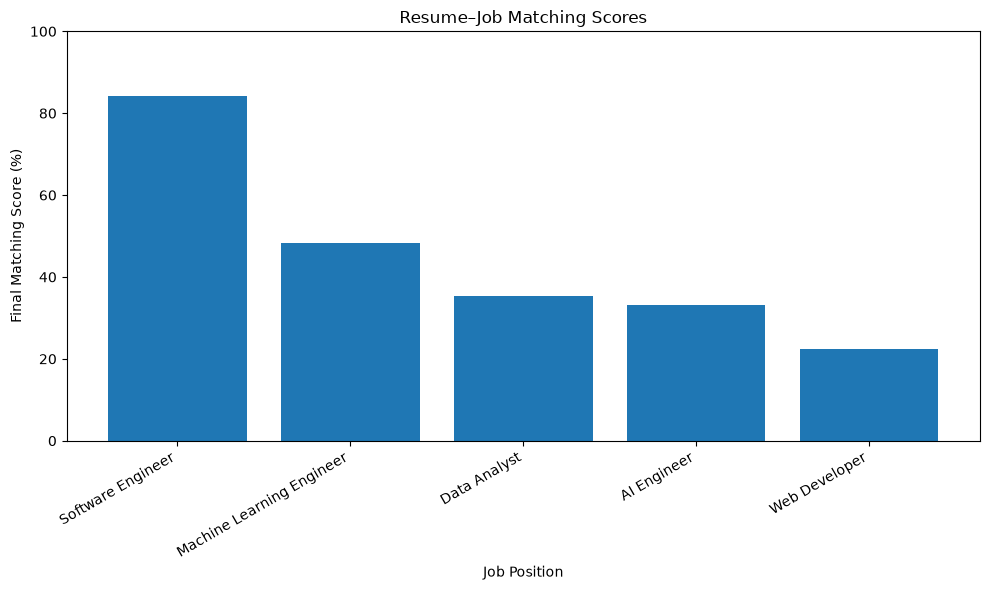

In [17]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_results["job_title"],
    final_results["final_score"]
)

plt.title("Resume–Job Matching Scores")
plt.xlabel("Job Position")
plt.ylabel("Final Matching Score (%)")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.ylim(0, 100)

plt.tight_layout()

plt.show()

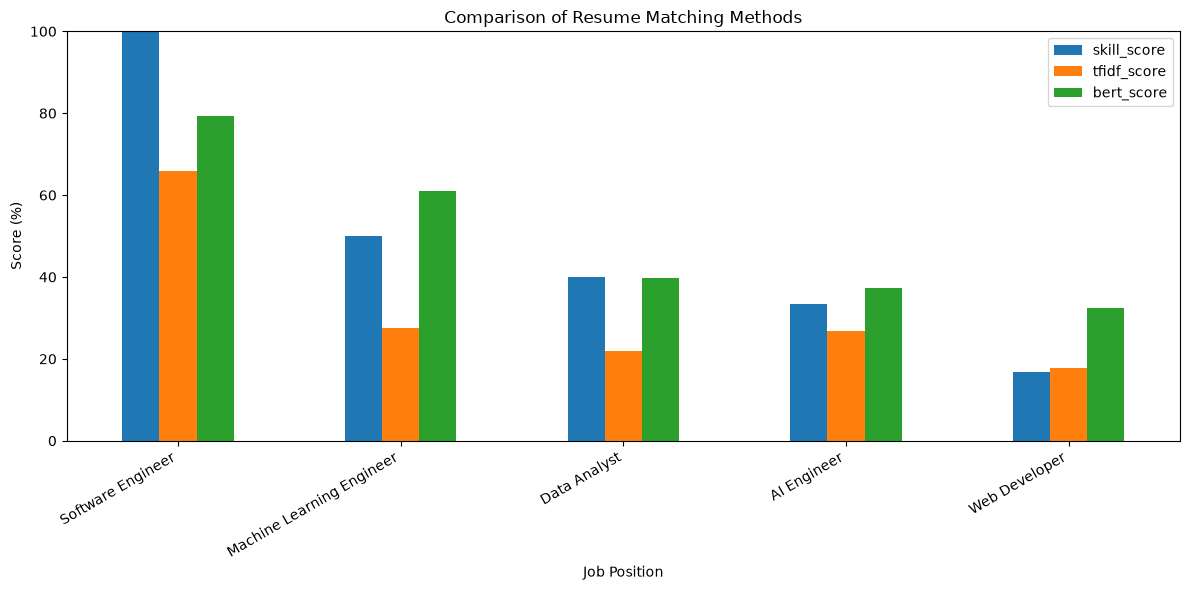

In [18]:
comparison_df = final_results[
    [
        "job_title",
        "skill_score",
        "tfidf_score",
        "bert_score"
    ]
].copy()

comparison_df = comparison_df.set_index("job_title")

comparison_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Resume Matching Methods")
plt.xlabel("Job Position")
plt.ylabel("Score (%)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [19]:
best_job = final_results.iloc[0]

print("🏆 Best Matching Job")
print("----------------------------")
print("Job Title:", best_job["job_title"])
print("Final Score:", round(best_job["final_score"], 2), "%")
print("Recommendation:", best_job["recommendation"])

🏆 Best Matching Job
----------------------------
Job Title: Software Engineer
Final Score: 84.25 %
Recommendation: Highly Recommended


In [ ]:
## Conclusion

The AI Resume Screening System successfully combines Natural Language Processing, skill extraction, TF-IDF similarity, and BERT-based semantic similarity to evaluate resume suitability for different job positions.

For the sample resume used in this analysis, the Software Engineer position achieved the highest matching score of 84.25% and was classified as Highly Recommended.

The results demonstrate that combining explicit skill matching with traditional text similarity and semantic BERT similarity provides a more comprehensive approach to resume-job matching.